In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
cases_df = pd.read_csv("cases.tsv", sep='\t')
entitlements_df = pd.read_stata("all_entitlements.dta")

In [6]:
cases_df.head()

,case_name,CEQA,names,names_count,parking_mentions,affordability_mentions,community_mentions,num_words,num_nonstopgap_words,sentiment_pos,sentiment_neg,sentiment_neutral,date,area,txt_file_name
0,01DepartmentalRepor,NaN,[],0,1,0,0,203,122,0.256825,0.009197,0.733978,01-05-2011,West,txt/01-05-10audio_01DepartmentalReport.txt
1,02CommissionBusines,NaN,[],0,1,0,1,810,419,0.099221,0.269955,0.630824,01-05-2011,West,txt/01-05-10audio_02CommissionBusiness.txt
2,03ZA09-2885&04ZA09-2886,ENV-2009-2884-CE,"[('David', 'Carlat')]",1,9,0,3,9972,5145,0.064828,0.214557,0.720616,01-05-2011,West,txt/01-05-10audio_03ZA09-2885_04ZA09-2886b.txt
3,04ZA09-2886,NaN,[],0,0,0,1,496,278,0.059718,0.099156,0.841126,01-05-2011,West,txt/01-05-10audio_04ZA09-2886.txt
4,05APCW10-657,ENV-2009-2730-MND-REC1,"[('Melissa', 'Talber')]",1,0,0,0,917,509,0.143066,0.052420,0.804515,01-05-2011,West,txt/01-05-10audio_05APCW10-657.txt


In [7]:
entitlements_df.head()

,case_number,case_determination,case_reviewer,primary_address,APC,assessor_parcel_number,certified_neighborhood_council,community_plan_area,short_description,entitlement,...,proposed_adding,proposed_to_be_demo,has_hearing,sanfernvalleyLA,southLA,northeastLA,eastLA,centralLA,westsideLA,harborLA
0,ENV-2017-782-EAF,,ENVIRONMENTAL,23133 W SHERMAN PL,SOUTH VALLEY,2021014053,West Hills,Canoga Park - Winnetka - Woodland Hills - West...,construction of a mixed use project consisting...,"vesting zone change, height district change, b...",...,127.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CPC-2017-781-VZCJ-HD-BL-SPR,,CITY PLANNING COMMISSION,23133 W SHERMAN PL,SOUTH VALLEY,2021014053,West Hills,Canoga Park - Winnetka - Woodland Hills - West...,construction of a mixed use project consisting...,"vesting zone change, height district change, b...",...,127.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ADM-2021-6072-TOC,REVIEW COMPLETED,ADMINISTRATIVE REVIEW,7403 N TOPANGA CANYON BLVD,SOUTH VALLEY,2023004015,Canoga Park,Canoga Park - Winnetka - Woodland Hills - West...,toc tier verification,toc tier verification,...,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ADM-2022-9386-TOC,REVIEW COMPLETED,ADMINISTRATIVE REVIEW,22155 W SHERMAN WAY,SOUTH VALLEY,2023009013,Canoga Park,Canoga Park - Winnetka - Woodland Hills - West...,n apartment building. 3 stories. fully sprink...,n apartment building. 3 stories. fully sprink...,...,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ADM-2021-778-TOC,REVIEW COMPLETED,ADMINISTRATIVE REVIEW,22015 W VANOWEN,SOUTH VALLEY,2024005025,Canoga Park,Canoga Park - Winnetka - Woodland Hills - West...,toc tier verification,toc tier verfication,...,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
cases_df["case_number"] = cases_df["CEQA"]
merged_df = pd.merge(cases_df, entitlements_df, on='case_number', how='inner') #Merges (inner) dataframes
merged_df.head()

,case_name,CEQA,names,names_count,parking_mentions,affordability_mentions,community_mentions,num_words,num_nonstopgap_words,sentiment_pos,...,proposed_adding,proposed_to_be_demo,has_hearing,sanfernvalleyLA,southLA,northeastLA,eastLA,centralLA,westsideLA,harborLA
0,6 CPC-2014-2947,ENV-2014-2948-MND,"[('Patty', 'Burman')]",1,32,17,1,9153,5110,0.354775,...,163.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,7 CPC-2016-1735,ENV-2016-1736-CE,"[('Kenikia', 'Gardner')]",1,18,1,1,3206,1723,0.276063,...,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,4 TT-73626,ENV-2016-1747-CE,"[('Courtney', 'Schum')]",1,1,1,1,8112,4244,0.095521,...,15.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,9 CPC-2016-2881,ENV-2016-2882-MND,"[('Peter', 'Jeans')]",1,5,2,4,2584,1434,0.306944,...,170.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6 VTT-72928,ENV-2014-4617-MND,"[('Robert', 'Sliduk'), ('Brad', 'Wise'), ('Ang...",4,33,7,3,6655,3557,0.176015,...,85.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


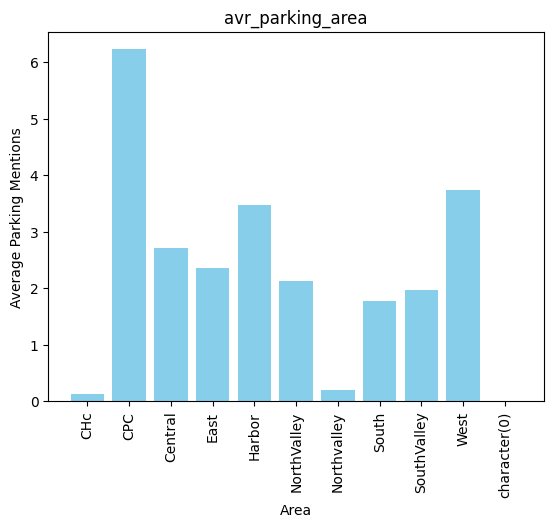

In [13]:
avr_parking_area = cases_df.groupby('area')['parking_mentions'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_parking_area['area'], avr_parking_area['parking_mentions'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Parking Mentions')
plt.title('parking_mentions')
plt.xticks(rotation=90)
plt.show()

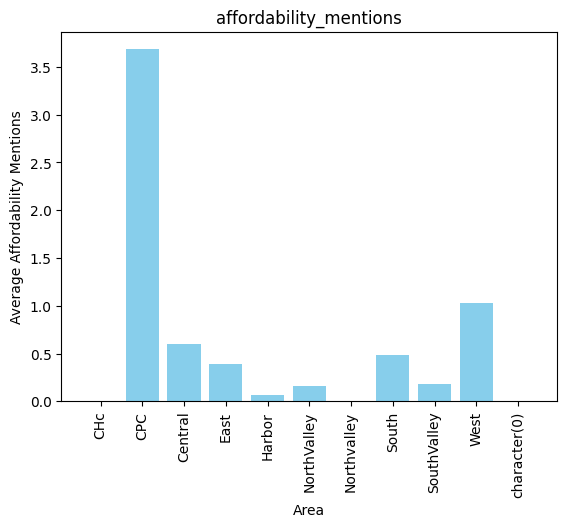

In [12]:
avr_aff_area = cases_df.groupby('area')['affordability_mentions'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_aff_area['area'], avr_aff_area['affordability_mentions'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Affordability Mentions')
plt.title('affordability_mentions')
plt.xticks(rotation=90)
plt.show()

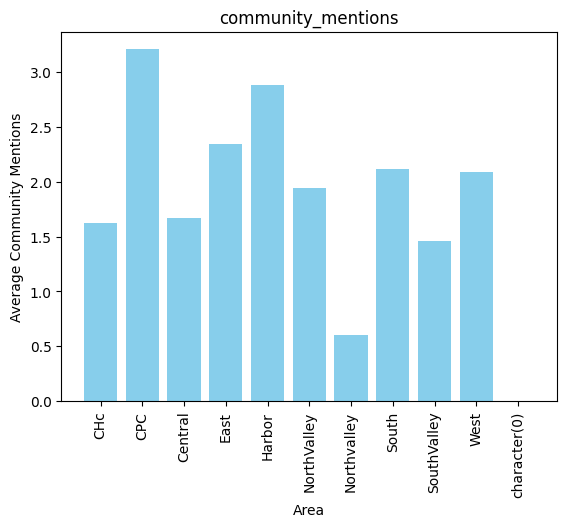

In [14]:
avr_comm_area = cases_df.groupby('area')['community_mentions'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_comm_area['area'], avr_comm_area['community_mentions'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Community Mentions')
plt.title('community_mentions')
plt.xticks(rotation=90)
plt.show()

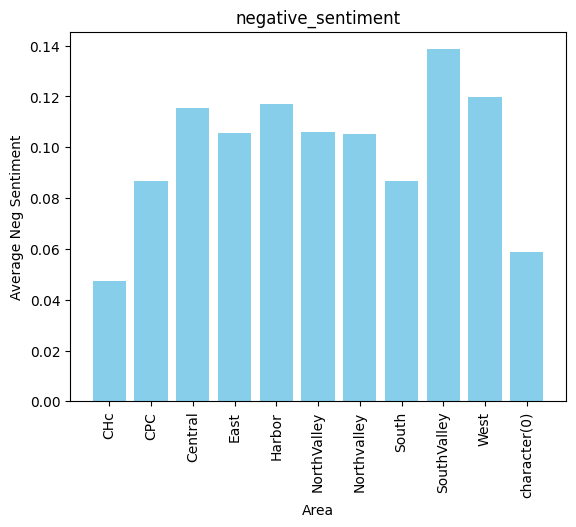

In [16]:
negative_sentiment = cases_df.groupby('area')['sentiment_neg'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(negative_sentiment['area'], negative_sentiment['sentiment_neg'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Neg Sentiment')
plt.title('negative_sentiment')
plt.xticks(rotation=90)
plt.show()

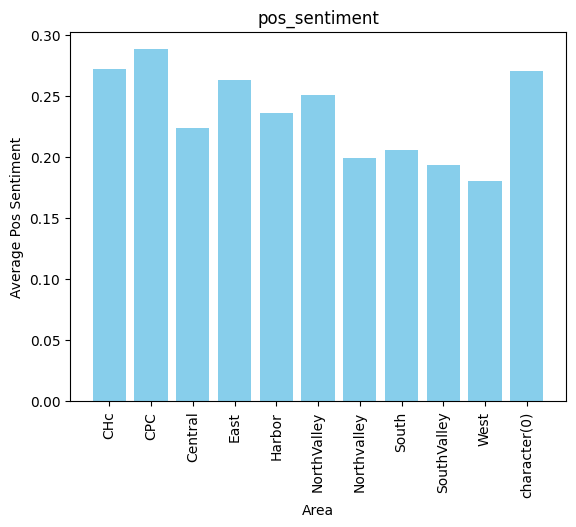

In [19]:
pos_sentiment = cases_df.groupby('area')['sentiment_pos'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(pos_sentiment['area'], pos_sentiment['sentiment_pos'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Pos Sentiment')
plt.title('pos_sentiment')
plt.xticks(rotation=90)
plt.show()

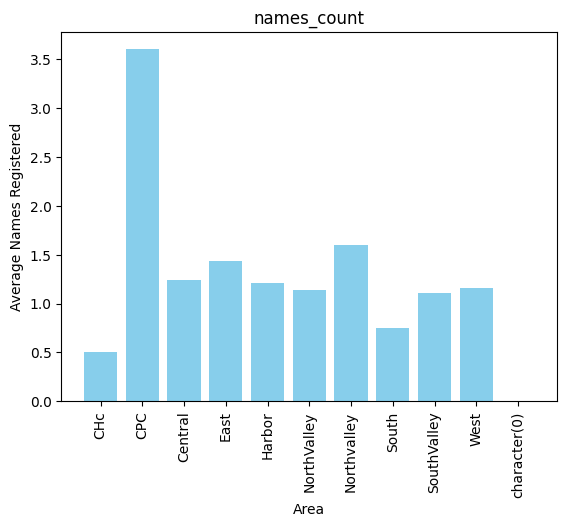

In [17]:
names_count = cases_df.groupby('area')['names_count'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(names_count['area'], names_count['names_count'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Names Registered')
plt.title('names_count')
plt.xticks(rotation=90)
plt.show()

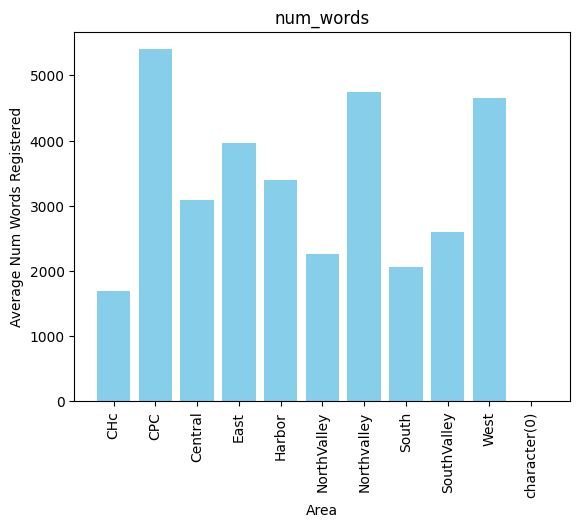

In [20]:
num_words = cases_df.groupby('area')['num_words'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(num_words['area'], num_words['num_words'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Num Words Registered')
plt.title('num_words')
plt.xticks(rotation=90)
plt.show()

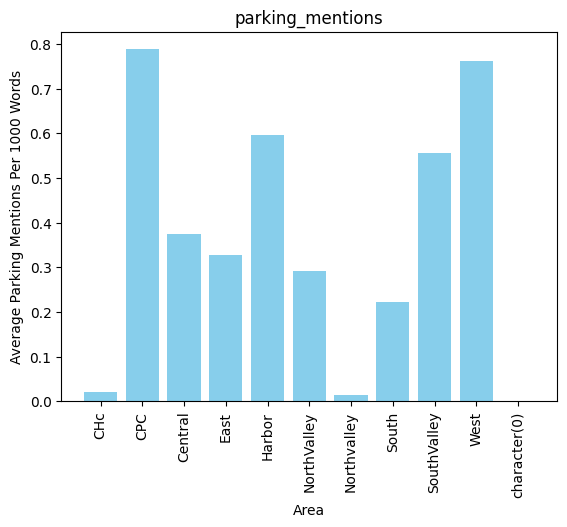

In [23]:
cases_df["parking_per_1000"] = cases_df.apply(lambda row: row['parking_mentions'] / row['num_words'] * 1000 if row['num_words'] > 0 else 0, axis=1)
avr_parking_area = cases_df.groupby('area')['parking_per_1000'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_parking_area['area'], avr_parking_area['parking_per_1000'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average Parking Mentions Per 1000 Words')
plt.title('parking_mentions_per_1000')
plt.xticks(rotation=90)
plt.show()

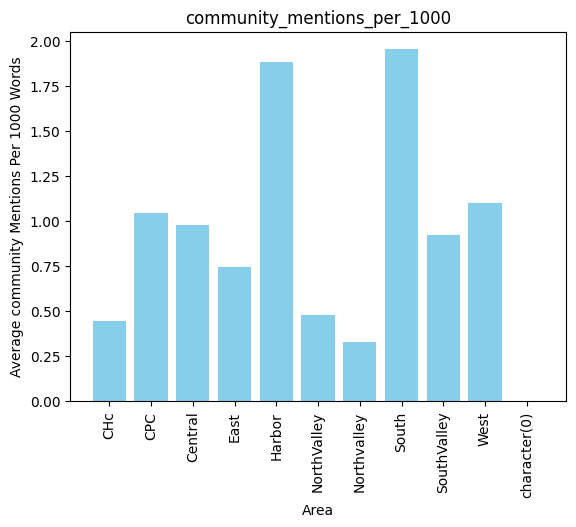

In [24]:
cases_df["community_per_1000"] = cases_df.apply(lambda row: row['community_mentions'] / row['num_words'] * 1000 if row['num_words'] > 0 else 0, axis=1)
avr_community_area = cases_df.groupby('area')['community_per_1000'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_community_area['area'], avr_community_area['community_per_1000'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average community Mentions Per 1000 Words')
plt.title('community_mentions_per_1000')
plt.xticks(rotation=90)
plt.show()

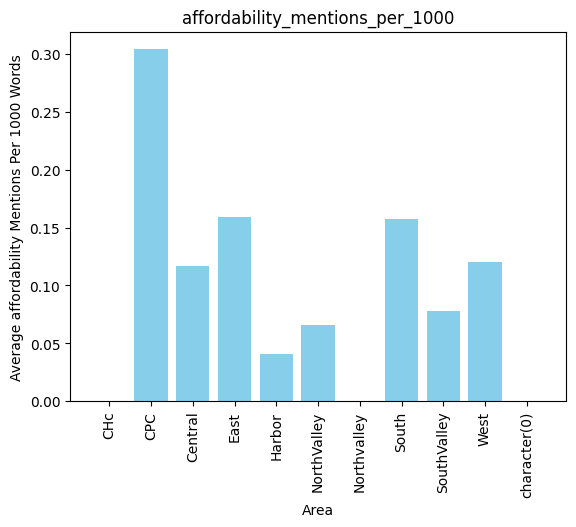

In [25]:
cases_df["affordability_per_1000"] = cases_df.apply(lambda row: row['affordability_mentions'] / row['num_words'] * 1000 if row['num_words'] > 0 else 0, axis=1)
avr_affordability_area = cases_df.groupby('area')['affordability_per_1000'].mean().reset_index()

# Plotting the data
plt.figure()
plt.bar(avr_affordability_area['area'], avr_affordability_area['affordability_per_1000'], color='skyblue')
plt.xlabel('Area')
plt.ylabel('Average affordability Mentions Per 1000 Words')
plt.title('affordability_mentions_per_1000')
plt.xticks(rotation=90)
plt.show()